# Quantum vs Classical SVM on PBMC3k — Qubit Scaling Curve

## Objective

Reproduce Figure 2 from **Zhao et al. (2026)** in classical simulation: 
comparing classifier performance as a function of the number of qubits/features (4, 8, 12, 16, 20), evaluating three models:

1. **RBF SVM** — classical baseline, rbf kernel with `class_weight='balanced'`
2. **Quantum Kernel SVM (IQP)** — precomputed IQP kernel, OvR, C tuning, `class_weight='balanced'`
3. **QOS (Quantum Oracle Sketching)** — streaming classifier without storing the full Gram matrix

### Experimental Setup

| Qubits | N samples | IQP repeats |
|--------|-----------|-------------|
| 4      | 800       | 2           |
| 8      | 650       | 2           |
| 12     | 500       | 1           |
| 16     | 350       | 1           |
| 20     | 200       | 1           |

N is reduced as the number of qubits increases to keep the total compute time at ~1h. 
This forced reduction is a result in itself: it illustrates why actual QOS (which does not need the Gram matrix) is necessary for large N.

## 1. Imports and Configuration

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import os
import json

warnings.filterwarnings('ignore')

import scanpy as sc
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

import pennylane as qml
from pennylane import numpy as pnp

sc.settings.verbosity = 1
np.random.seed(42)

# Data save directories
DATA_DIR  = "data"
GRAM_DIR  = "gram_matrices"  
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(GRAM_DIR,  exist_ok=True)

# GPU detector
def get_pennylane_device(n_wires):
    """Uses lightning.gpu if possible, fallback to lightning.qubit otherwise."""
    try:
        dev = qml.device('lightning.gpu', wires=n_wires)
        print(f"  Using lightning.gpu ({n_wires} wires)")
        return dev
    except Exception:
        print(f"  GPU no available — using lightning.qubit ({n_wires} wires)")
        return qml.device('lightning.qubit', wires=n_wires)

## 2. Loading and pre-processing of dataset PBMC3k

In [ ]:
CACHE_PATH = os.path.join(DATA_DIR, "pbmc3k_preprocessed.h5ad")

if os.path.exists(CACHE_PATH):
    print(f"Cache local found in '{CACHE_PATH}' — loading...")
    adata = sc.read_h5ad(CACHE_PATH)
    print(f"  {adata.n_obs} cells × {adata.n_vars} genes")
else:
    print("Downloading and preprocessing PBMC3k...")

    adata = sc.datasets.pbmc3k()

    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    adata = adata[adata.obs.pct_counts_mt < 5, :]
    adata = adata[adata.obs.n_genes_by_counts < 2500, :]

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata = adata[:, adata.var.highly_variable]
    sc.pp.scale(adata, max_value=10)

    sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.9)

    cell_type_map = {
        '0': 'CD4 T cells', '1': 'CD14 Monocytes', '2': 'B cells',
        '3': 'CD8 T cells', '4': 'NK cells',       '5': 'FCGR3A Monocytes',
        '6': 'Dendritic cells', '7': 'Megakaryocytes'
    }
    adata.obs['cell_type'] = adata.obs['leiden'].map(
        lambda x: cell_type_map.get(x, f'Cluster {x}')
    )
    adata.write_h5ad(CACHE_PATH)
    print(f"✓ Guardado en '{CACHE_PATH}'")

label_col = 'cell_type' if 'cell_type' in adata.obs.columns else 'leiden'

# Remove 2 minority classes
classes_to_remove = ['Dendritic cells', 'Megakaryocytes']
adata = adata[~adata.obs[label_col].isin(classes_to_remove)].copy()
if adata.obs[label_col].dtype.name == 'category':
    adata.obs[label_col] = adata.obs[label_col].cat.remove_unused_categories()


print(f"\nDistribution of celular types:")
print(adata.obs[label_col].value_counts())

Cache local found in 'data/pbmc3k_preprocessed.h5ad' — loading...
  2638 células × 1838 genes

Distribution of celular types:
cell_type
CD4 T cells         1152
CD14 Monocytes       422
B cells              341
CD8 T cells          302
NK cells             217
FCGR3A Monocytes     155
Name: count, dtype: int64


## 3. Configuration of experiment

5 points in scale curve: 4, 8, 12, 16, 20 qubits.
Each point uses a diferent number of samples to mantain a reasonable computation time.

In [28]:
# Configuration of curve points
# (n_qubits, n_features, n_samples, iqp_repeats)
CURVE_CONFIGS = [
    (4,  4,  800, 2),
    (8,  8,  650, 2),
    (12, 12, 500, 1),
    (16, 16, 350, 1),
    (20, 20, 200, 1),
]

# C Tuning for Quantum Kernel
C_GRID = [0.1, 1.0, 10.0, 100.0, 1000.0]

# Extract 50 componentes PCA already calculated by scanpy
X_pca50 = adata.obsm['X_pca']  # shape (2638, 50)

# Encode labels
le = LabelEncoder()
y_all = le.fit_transform(adata.obs[label_col].values)
class_names = le.classes_
n_classes   = len(class_names)

print(f"Classes ({n_classes}): {list(class_names)}")
print(f"\nPoints of Curve:")
print(f"{'Qubits':>8} {'Features':>10} {'N samples':>12} {'IQP repeats':>13}")
print("-" * 48)
for n_q, n_f, n_s, n_r in CURVE_CONFIGS:
    print(f"{n_q:>8} {n_f:>10} {n_s:>12} {n_r:>13}")

Classes (6): ['B cells', 'CD14 Monocytes', 'CD4 T cells', 'CD8 T cells', 'FCGR3A Monocytes', 'NK cells']

Points of Curve:
  Qubits   Features    N samples   IQP repeats
------------------------------------------------
       4          4          800             2
       8          8          650             2
      12         12          500             1
      16         16          350             1
      20         20          200             1


## 4. Auxiliar Functions

### 4.1 Kernel IQP and Gram matrix calculation

In [29]:
def build_iqp_kernel(n_qubits, n_repeats):
    """
    Builds the IQP kernel function for given n_qubits and n_repeats. 
    Uses lightning.gpu if available.
    """
    dev = get_pennylane_device(n_qubits)

    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        qml.IQPEmbedding(x1, wires=range(n_qubits), n_repeats=n_repeats)
        qml.adjoint(qml.IQPEmbedding)(x2, wires=range(n_qubits), n_repeats=n_repeats)
        return qml.probs(wires=range(n_qubits))

    def kernel(x1, x2):
        return float(kernel_circuit(x1, x2)[0])

    return kernel


def compute_gram_matrix(kernel_fn, X1, X2=None):
    """
    Computes the Gram matrix sequentially to avoid thread collisions in PennyLane/GPU.
    """
    symmetric = X2 is None
    if symmetric:
        X2 = X1

    n1, n2 = len(X1), len(X2)

    if symmetric:
        # Upper triangle only, then symmetrize
        pairs = [(i, j) for i in range(n1) for j in range(i, n2)]
    else:
        pairs = [(i, j) for i in range(n1) for j in range(n2)]

    print(f" Calculating {len(pairs):,} evaluations of kernel...")
    t0 = time.time()

    # Bucle secuencial estándar (Seguro para PennyLane y GPU)
    results = []
    for i, j in pairs:
        results.append(kernel_fn(X1[i], X2[j]))

    K = np.zeros((n1, n2))
    for (i, j), v in zip(pairs, results):
        K[i, j] = v
        if symmetric:
            K[j, i] = v

    elapsed = time.time() - t0
    print(f"Gram matrix ({n1}×{n2}) calculated in {elapsed/60:.1f} min")
    return K


def check_kernel_concentration(K_train, label=""):
    """
    Detects kernel collapse (kernel concentration). 
    If off-diagonal variance is too low, the kernel is not informative.
    """
    off_diag = K_train[np.triu_indices_from(K_train, k=1)]
    var  = off_diag.var()
    mean = off_diag.mean()
    print(f"    Kernel {label}: mean={mean:.4f}, variance={var:.6f}", end="")
    if var < 1e-4:
        print(" KERNEL CONCENTRATION — unreliable results")
    else:
        print(" ✓")
    return var

### 4.2 QOS — Quantum Oracle Sketching (Nyström + Linear SVM)

To avoid storing the entire Gram matrix ($\mathcal{O}(N^2)$ in memory), this method uses an empirical feature mapping inspired by Nyström's approximation:
- Select a stratified subset of $L$ training samples (`n_landmarks`).
- Transform each sample of the original data by evaluating the quantum kernel only against the $L$ landmarks, generating a vector of size $L$.
- Train a classic `LinearSVC` classifier on these projected features.

This simulates a memory regime $\mathcal{O}(N \times L)$, allowing scaling to a larger number of samples without collapsing the simulator's memory.

In [ ]:
class QOSClassifier:
    """
    Quantum Nyström Sketching + Linear SVM.
    Transforms data by measuring its quantum similarity against L landmarks,
    and then uses a classical linear model to find the optimal boundary.

    Memory: O(N * n_landmarks) instead of O(N^2).
    """
    def __init__(self, kernel_fn, n_landmark=100, class_weight='balanced', random_state=42):
        self.kernel_fn    = kernel_fn
        self.n_landmark   = n_landmark
        self.class_weight = class_weight
        self.random_state = random_state
        
        self.clf = OneVsRestClassifier(
            LinearSVC(class_weight=class_weight, random_state=random_state, dual=False)
        )

    def _get_sketched_features(self, X):
        """Transform the data by calculating the kernel against the landmarks"""
        n_samples = len(X)
        n_l = len(self.landmarks_)
        X_sketched = np.zeros((n_samples, n_l))
        
        for i, x in enumerate(X):
            X_sketched[i, :] = [self.kernel_fn(x, lm) for lm in self.landmarks_]
            
        return X_sketched

    def fit(self, X_train, y_train):
        rng = np.random.RandomState(self.random_state)
        self.classes_ = np.unique(y_train)

        # Select stratified landmarks
        landmark_idx = []
        per_class = max(1, self.n_landmark // len(self.classes_))
        for c in self.classes_:
            idx_c = np.where(y_train == c)[0]
            chosen = rng.choice(idx_c, size=min(per_class, len(idx_c)), replace=False)
            landmark_idx.extend(chosen.tolist())
            
        remaining = self.n_landmark - len(landmark_idx)
        if remaining > 0:
            extra = rng.choice(len(X_train), size=remaining, replace=False)
            landmark_idx.extend(extra.tolist())
            
        self.landmarks_ = X_train[np.array(landmark_idx)]

        # Sketching (Quantum proyection of train)
        print(f"    Projecting {len(X_train)} samples against {len(self.landmarks_)} landmarks...")
        t0 = time.time()
        X_train_sketched = self._get_sketched_features(X_train)
        print(f"    Projection finished in {(time.time()-t0)/60:.1f} min. Training Linear SVM...")

        # Train the linear classifier on quantum features
        self.clf.fit(X_train_sketched, y_train)
        
        return self

    def predict(self, X_test):
        # Test Sketching
        X_test_sketched = self._get_sketched_features(X_test)
        # Prediction
        return self.clf.predict(X_test_sketched)

### 4.3 Evaluation and Tuning of C

In [31]:
def evaluate_model(name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  F1 (macro) : {f1*100:.2f}%")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return acc, f1


def tune_C_quantum(K_train, y_train, C_grid, cv=3):
    """
    Searches for the best C for a precomputed kernel using cross-validation. 
    Uses sample weights for class_weight='balanced'.
    """
    best_C, best_score = C_grid[0], -1
    sample_weights = compute_sample_weight('balanced', y_train)

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    for C in C_grid:
        scores = []
        for train_idx, val_idx in skf.split(K_train, y_train):
            K_tr  = K_train[np.ix_(train_idx, train_idx)]
            K_val = K_train[np.ix_(val_idx,   train_idx)]
            y_tr  = y_train[train_idx]
            y_val = y_train[val_idx]
            sw_tr = sample_weights[train_idx]

            svm = OneVsRestClassifier(
                SVC(kernel='precomputed', C=C, random_state=42, class_weight='balanced')
            )
            svm.fit(K_tr, y_tr)
            pred = svm.predict(K_val)
            scores.append(f1_score(y_val, pred, average='macro', zero_division=0))

        mean_score = np.mean(scores)
        print(f"      C={C:>8}: F1 macro CV = {mean_score:.4f}")
        if mean_score > best_score:
            best_score = mean_score
            best_C     = C

    print(f"Best C: {best_C} (F1={best_score:.4f})")
    return best_C

## 5. Main loop — qubit scaling curve

For each point (n_qubits, n_features, N):
1. Weighted subsampling (class_weight)
2. PCA to n_features components + MinMaxScaler → [0, π]
3. Linear SVM (baseline)
4. Quantum Kernel SVM with C tuning
5. QOS

In [ ]:
# Store results for all points on the curve
curve_results = []

for (n_qubits, n_features, N_SAMPLES, n_repeats) in CURVE_CONFIGS:

    print(f"\n{'#'*65}")
    print(f"# EXPERIMENT: {n_qubits} qubits / {n_features} features / N={N_SAMPLES}")
    print(f"{'#'*65}")

    # 5.1 Subsampling of Class Weights

    # Instead of forced stratification, subsample with probability 
    # proportional to inverse class weight (balanced)
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight('balanced', classes=np.unique(y_all), y=y_all)
    sample_prob = np.array([cw[y] for y in y_all])
    sample_prob = sample_prob / sample_prob.sum()

    rng = np.random.RandomState(42)
    idx_sampled = rng.choice(len(y_all), size=N_SAMPLES, replace=False, p=sample_prob)

    X_sub = X_pca50[idx_sampled]   # use 50 PCs of scanpy
    y_sub = y_all[idx_sampled]

    print(f"\nDistribution after subsampling weighted (N={N_SAMPLES}):")
    for c, name in enumerate(class_names):
        print(f"  {name:20s}: {np.sum(y_sub == c):3d}")

    # 5.2 Train/test split

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    # 5.3 Selecting PCA

    # Select first n_features columns, the ones with more variance
    X_train_red = X_train_raw[:, :n_features]
    X_test_red  = X_test_raw[:, :n_features]

    # Extract the variance ratio already calculated by Scanpy (a PCA with 50 PCs)
    var_ratio_scanpy = adata.uns['pca']['variance_ratio']
    var_explained = var_ratio_scanpy[:n_features].sum() * 100

    print(f"\nVariance explained with the top {n_features} PCs: {var_explained:.1f}%")

    # Scale to [0, π] for IQPEmbedding
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_train = scaler.fit_transform(X_train_red)
    X_test  = scaler.transform(X_test_red)
    
    sw_train = compute_sample_weight('balanced', y_train)

    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    result = {
        'n_qubits':   n_qubits,
        'n_features': n_features,
        'N_samples':  N_SAMPLES,
        'n_repeats':  n_repeats,
    }

    
    # MODEL A: RGB SVM (classical baseline)
    
    print(f"\n[A] RBF SVM (baseline)")
    t0 = time.time()
    svm_rbf = OneVsRestClassifier(
        SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
    )
    svm_rbf.fit(X_train, y_train)
    pred_rbf = svm_rbf.predict(X_test)
    t_rbf = time.time() - t0

    acc_rbf, f1_rbf = evaluate_model(
        f'RBF SVM ({n_features} features)', y_test, pred_rbf, class_names
    )
    print(f"Time: {t_rbf:.1f}s")
    result.update({
        'acc_rbf': acc_rbf, 
        'f1_rbf': f1_rbf, 
        'y_test': y_test, 
        'pred_rbf': pred_rbf
    })
    
    # MODEL B: Quantum Kernel SVM (IQP)
    
    print(f"\n[B] Quantum Kernel SVM (IQP, {n_qubits} qubits, {n_repeats} repeats)")

    # Build Kernel
    kernel_fn = build_iqp_kernel(n_qubits, n_repeats)

    # Gram matrix — load from disk if it already exists
    gram_path_train = os.path.join(GRAM_DIR, f"K_train_q{n_qubits}_N{N_SAMPLES}.npy")
    gram_path_test  = os.path.join(GRAM_DIR, f"K_test_q{n_qubits}_N{N_SAMPLES}.npy")

    if os.path.exists(gram_path_train) and os.path.exists(gram_path_test):
        print(f" Gram matrices loaded from disc")
        K_train = np.load(gram_path_train)
        K_test  = np.load(gram_path_test)
    else:
        print(f" Calculating K_train ({len(X_train)}×{len(X_train)})...")
        K_train = compute_gram_matrix(kernel_fn, X_train)
        np.save(gram_path_train, K_train)

        print(f" Calculating K_test ({len(X_test)}×{len(X_train)})...")
        K_test = compute_gram_matrix(kernel_fn, X_test, X_train)
        np.save(gram_path_test, K_test)
        print(f" Gram matrices saved in {GRAM_DIR}/")

    # Kernel collapse detection
    kvar = check_kernel_concentration(K_train, label=f"IQP {n_qubits}q")
    result['kernel_variance'] = kvar

    # Tuning of C
    print(f"  Tuning of C (grid={C_GRID}, CV=3)...")
    best_C = tune_C_quantum(K_train, y_train, C_GRID, cv=3)

    # Final training with best C
    t0 = time.time()
    svm_q = OneVsRestClassifier(
        SVC(kernel='precomputed', C=best_C, random_state=42, class_weight='balanced')
    )
    svm_q.fit(K_train, y_train)
    pred_q = svm_q.predict(K_test)
    t_q = time.time() - t0

    acc_q, f1_q = evaluate_model(
        f'Quantum SVM IQP ({n_qubits}q, C={best_C})', y_test, pred_q, class_names
    )
    print(f"  Time SVM (post-kernel): {t_q:.1f}s | Best C: {best_C}")
    result.update({'acc_quantum': acc_q, 'f1_quantum': f1_q,
                   'best_C': best_C, 'kernel_var': kvar, 'pred_q': pred_q})

    
    # MODEL C: QOS streaming
    print(f"\n[C] QOS Streaming ({n_qubits} qubits, {n_repeats} repeats)")
    print(f"    (without Gram matrix completed — memory O(n_landmark * n_classes))")

    n_landmark = 100

    t0 = time.time()
    qos = QOSClassifier(
        kernel_fn=kernel_fn,
        n_landmark=n_landmark,
        class_weight='balanced',
        random_state=42
    )
    qos.fit(X_train, y_train)
    pred_qos = qos.predict(X_test)
    t_qos = time.time() - t0

    acc_qos, f1_qos = evaluate_model(
        f'QOS Streaming ({n_qubits}q, {n_landmark} landmarks)', y_test, pred_qos, class_names
    )
    print(f"QOS Time: {t_qos/60:.1f} min")
    result.update({'acc_qos': acc_qos, 'f1_qos': f1_qos, 'pred_qos': pred_qos})

    # Summary of Point
    print(f"\n{'─'*52}")
    print(f"  Summary {n_qubits} qubits:")
    print(f"  {'Model':30s} {'Acc':>8} {'F1':>8}")
    print(f"  {'─'*48}")
    print(f"  {'RBF SVM':30s} {acc_rbf*100:>7.1f}% {f1_rbf*100:>7.1f}%")
    print(f"  {'Quantum SVM (IQP)':30s} {acc_q*100:>7.1f}% {f1_q*100:>7.1f}%")
    print(f"  {'QOS Streaming':30s} {acc_qos*100:>7.1f}% {f1_qos*100:>7.1f}%")

    curve_results.append(result)

print("\nExperiment completed.")


#################################################################
# EXPERIMENT: 4 qubits / 4 features / N=800
#################################################################

Distribution after subsampleing weighted (N=800):
  B cells             : 128
  CD14 Monocytes      : 149
  CD4 T cells         : 172
  CD8 T cells         : 126
  FCGR3A Monocytes    : 105
  NK cells            : 120

Variance explained with the top 4 PCs: 5.2%
Train: 640 | Test: 160

[A] RBF SVM (baseline)

  RBF SVM (4 features)
  Accuracy   : 89.38%
  F1 (macro) : 89.55%

                  precision    recall  f1-score   support

         B cells       1.00      1.00      1.00        26
  CD14 Monocytes       0.90      0.90      0.90        30
     CD4 T cells       0.91      0.85      0.88        34
     CD8 T cells       0.75      0.84      0.79        25
FCGR3A Monocytes       0.95      0.90      0.93        21
        NK cells       0.88      0.88      0.88        24

        accuracy                   

## 6. Scale Curve — principal result

Replicate Figure 2 if Zhao et al. (2026): performance vs number of qubits/features.

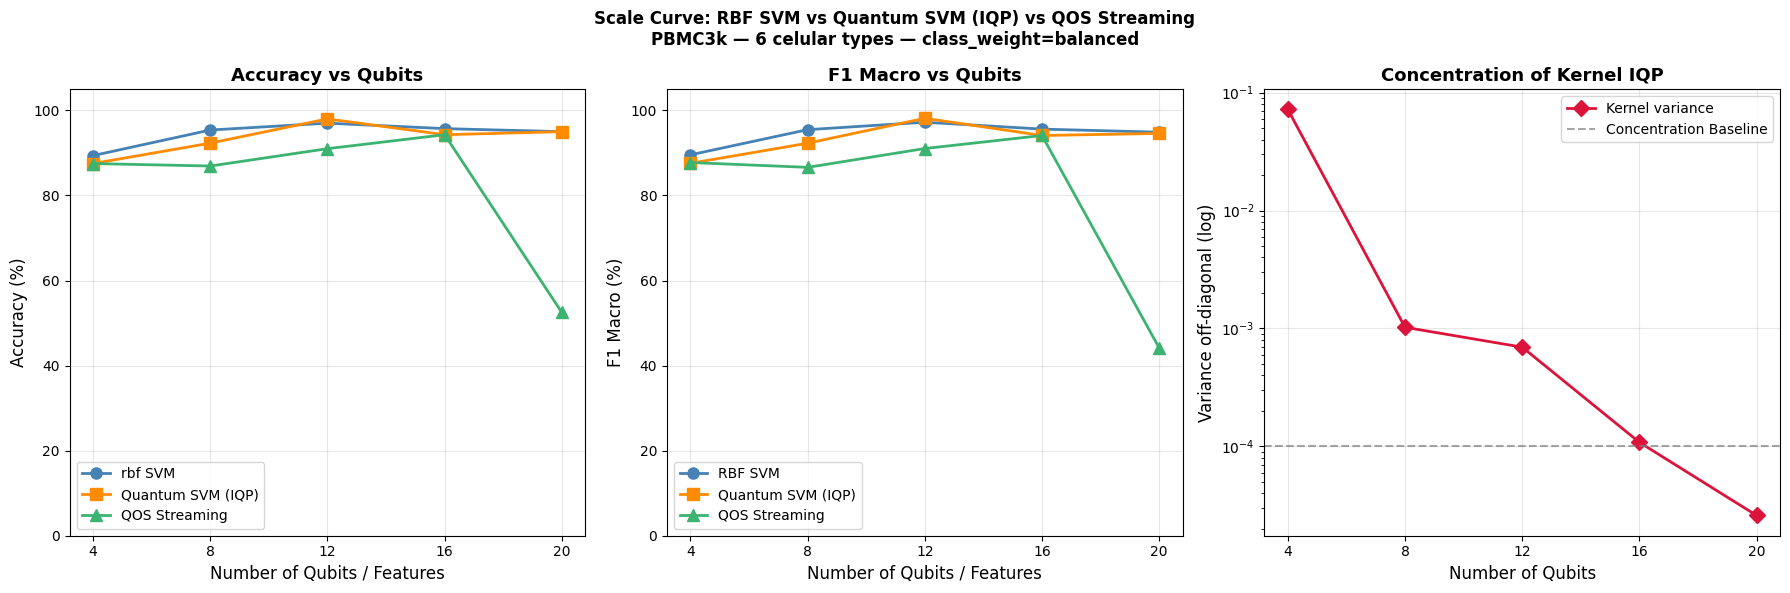

In [33]:
# Extract data for the curve
qubits_list  = [r['n_qubits']   for r in curve_results]
acc_rbf_list = [r['acc_rbf']    for r in curve_results]
acc_q_list   = [r['acc_quantum']  for r in curve_results]
acc_qos_list = [r['acc_qos']      for r in curve_results]
f1_rbf_list  = [r['f1_rbf']     for r in curve_results]
f1_q_list    = [r['f1_quantum']   for r in curve_results]
f1_qos_list  = [r['f1_qos']       for r in curve_results]
kvar_list    = [r.get('kernel_var', np.nan) for r in curve_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
ax = axes[0]
ax.plot(qubits_list, [v*100 for v in acc_rbf_list],  'o-', color='steelblue',
        linewidth=2, markersize=8, label='rbf SVM')
ax.plot(qubits_list, [v*100 for v in acc_q_list],   's-', color='darkorange',
        linewidth=2, markersize=8, label='Quantum SVM (IQP)')
ax.plot(qubits_list, [v*100 for v in acc_qos_list], '^-', color='mediumseagreen',
        linewidth=2, markersize=8, label='QOS Streaming')
ax.set_xlabel('Number of Qubits / Features', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Qubits', fontsize=13, fontweight='bold')
ax.set_xticks(qubits_list)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# F1 macro
ax = axes[1]
ax.plot(qubits_list, [v*100 for v in f1_rbf_list],  'o-', color='steelblue',
        linewidth=2, markersize=8, label='RBF SVM')
ax.plot(qubits_list, [v*100 for v in f1_q_list],   's-', color='darkorange',
        linewidth=2, markersize=8, label='Quantum SVM (IQP)')
ax.plot(qubits_list, [v*100 for v in f1_qos_list], '^-', color='mediumseagreen',
        linewidth=2, markersize=8, label='QOS Streaming')
ax.set_xlabel('Number of Qubits / Features', fontsize=12)
ax.set_ylabel('F1 Macro (%)', fontsize=12)
ax.set_title('F1 Macro vs Qubits', fontsize=13, fontweight='bold')
ax.set_xticks(qubits_list)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# Kernel Variance
ax = axes[2]
ax.semilogy(qubits_list, kvar_list, 'D-', color='crimson',
            linewidth=2, markersize=8, label='Kernel variance')
ax.axhline(1e-4, color='gray', linestyle='--', alpha=0.7, label='Concentration Baseline')
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('Variance off-diagonal (log)', fontsize=12)
ax.set_title('Concentration of Kernel IQP', fontsize=13, fontweight='bold')
ax.set_xticks(qubits_list)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(
    'Scale Curve: RBF SVM vs Quantum SVM (IQP) vs QOS Streaming\n'
    'PBMC3k — 6 celular types — class_weight=balanced',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 7. Summary table and best point confusion matrix

In [34]:
# Summary table with all points
print(f"{'Qubits':>8} {'N':>6} {'RBF Acc':>9} {'RBF F1':>8} "
      f"{'Q Acc':>8} {'Q F1':>8} {'QOS Acc':>9} {'QOS F1':>8} {'K var':>10} {'C opt':>8}")
print("-" * 90)
for r in curve_results:
    print(f"{r['n_qubits']:>8} {r['N_samples']:>6} "
          f"{r['acc_rbf']*100:>8.1f}% {r['f1_rbf']*100:>7.1f}% "
          f"{r['acc_quantum']*100:>7.1f}% {r['f1_quantum']*100:>7.1f}% "
          f"{r['acc_qos']*100:>8.1f}% {r['f1_qos']*100:>7.1f}% "
          f"{r.get('kernel_var', float('nan')):>10.2e} {r.get('best_C', '-'):>8}")

  Qubits      N   RBF Acc   RBF F1    Q Acc     Q F1   QOS Acc   QOS F1      K var    C opt
------------------------------------------------------------------------------------------
       4    800     89.4%    89.6%    87.5%    87.6%     87.5%    87.7%   7.20e-02     10.0
       8    650     95.4%    95.5%    92.3%    92.3%     86.9%    86.6%   1.02e-03      1.0
      12    500     97.0%    97.2%    98.0%    98.1%     91.0%    91.0%   6.94e-04      1.0
      16    350     95.7%    95.6%    94.3%    94.1%     94.3%    94.1%   1.08e-04     10.0
      20    200     95.0%    94.9%    95.0%    94.6%     52.5%    44.1%   2.60e-05      1.0


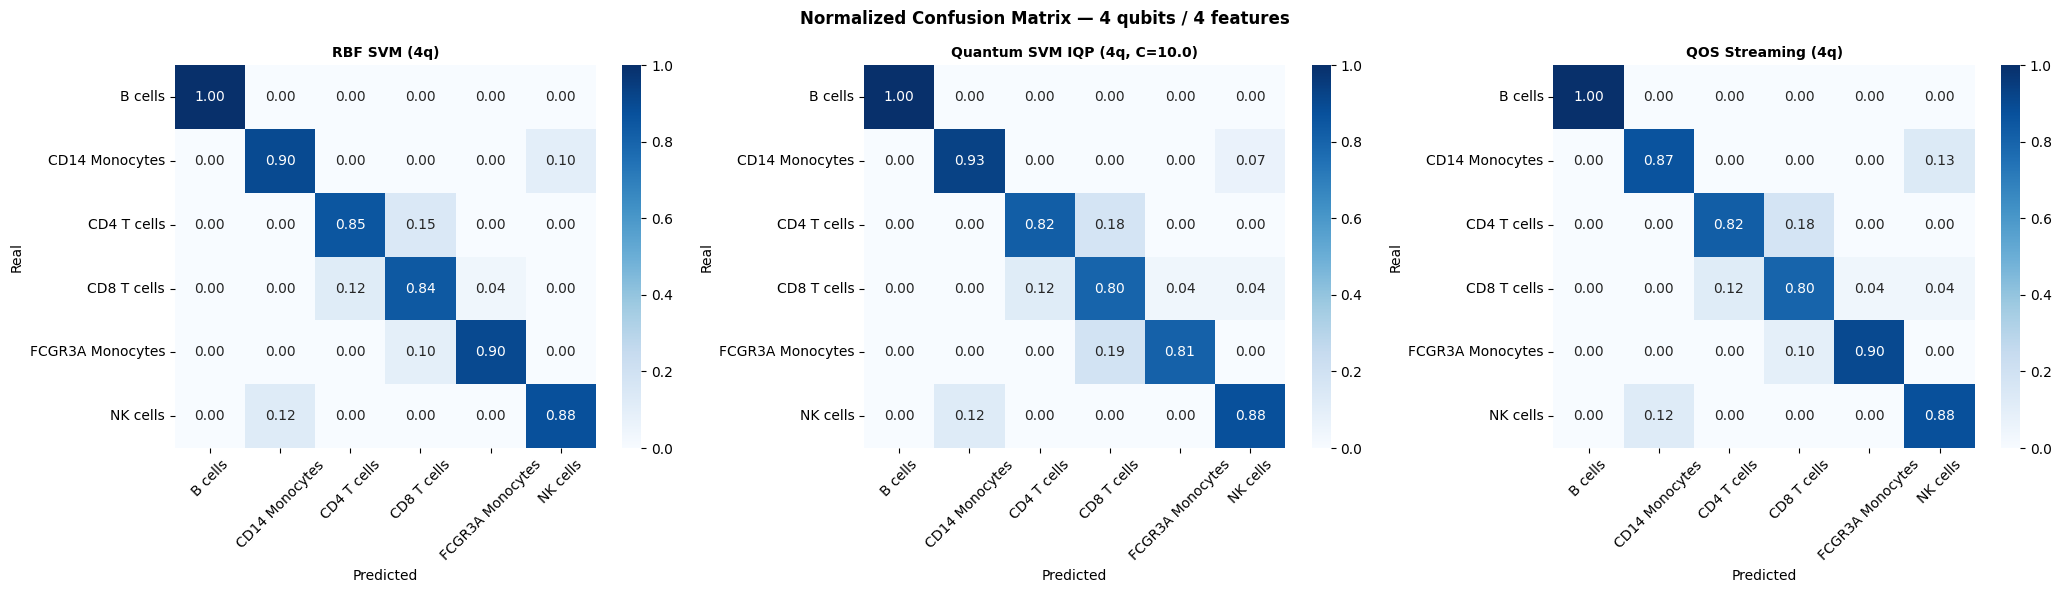

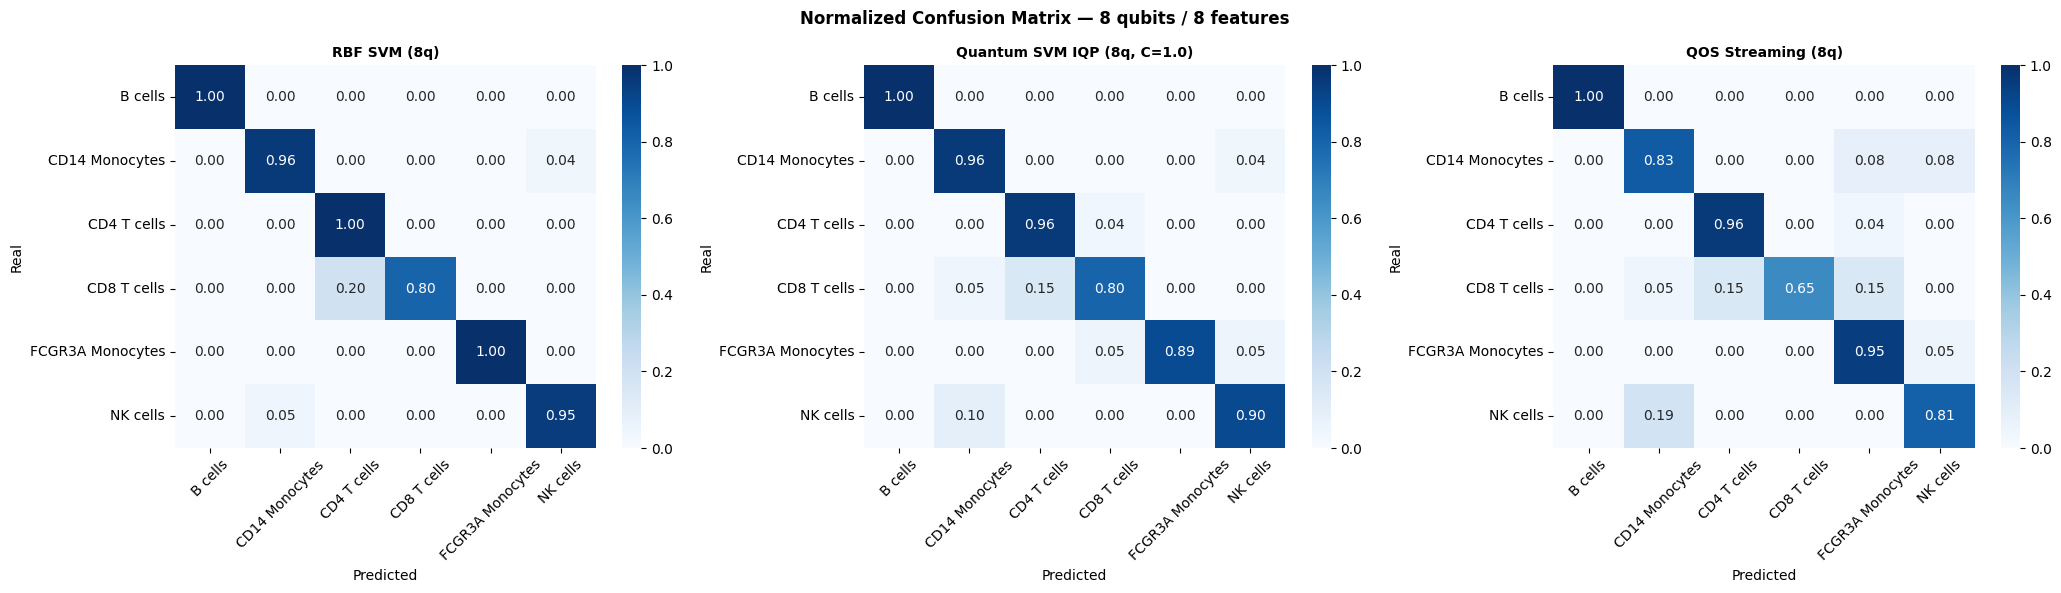

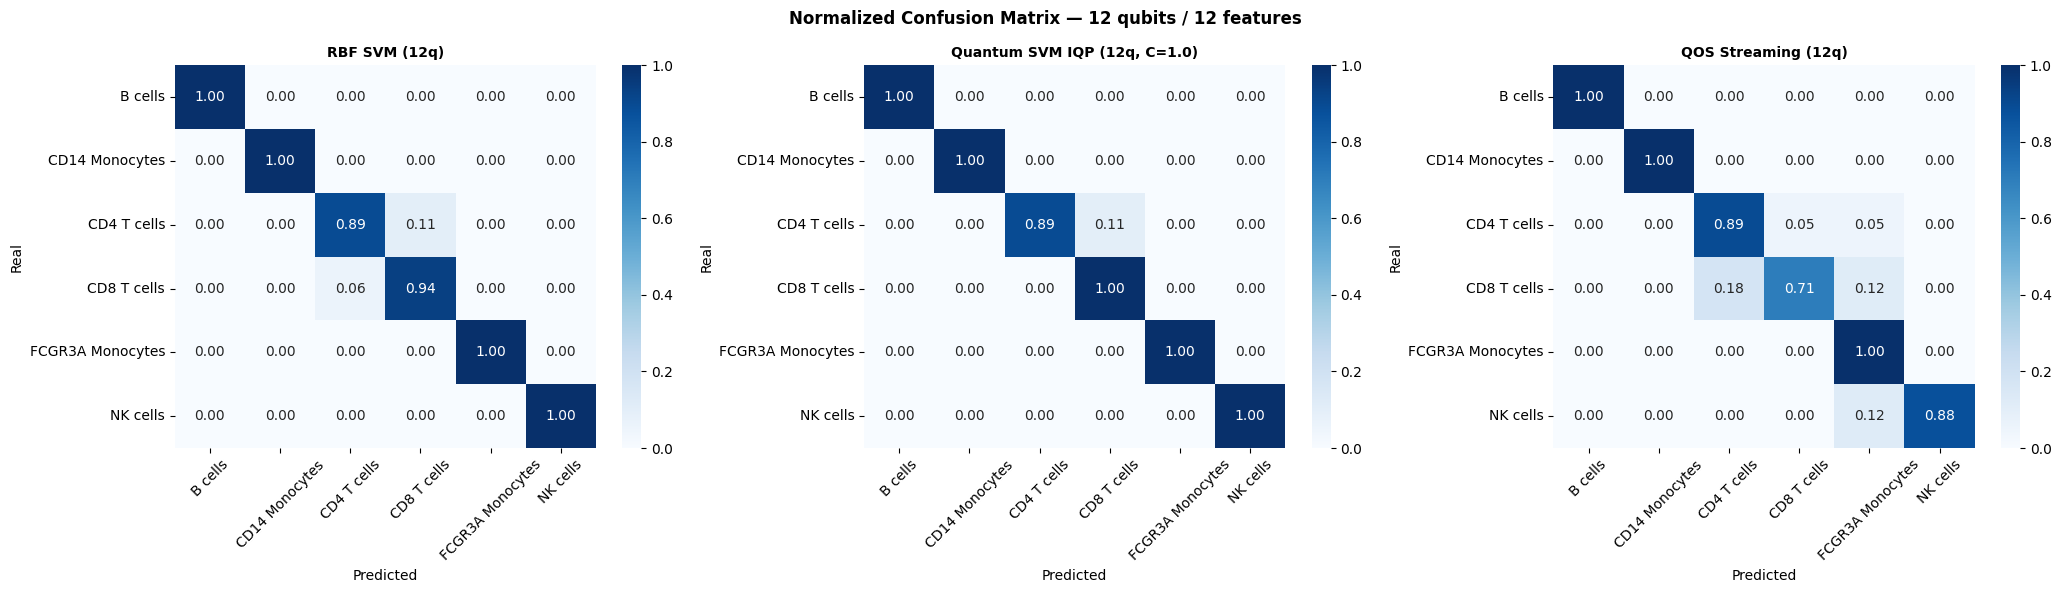

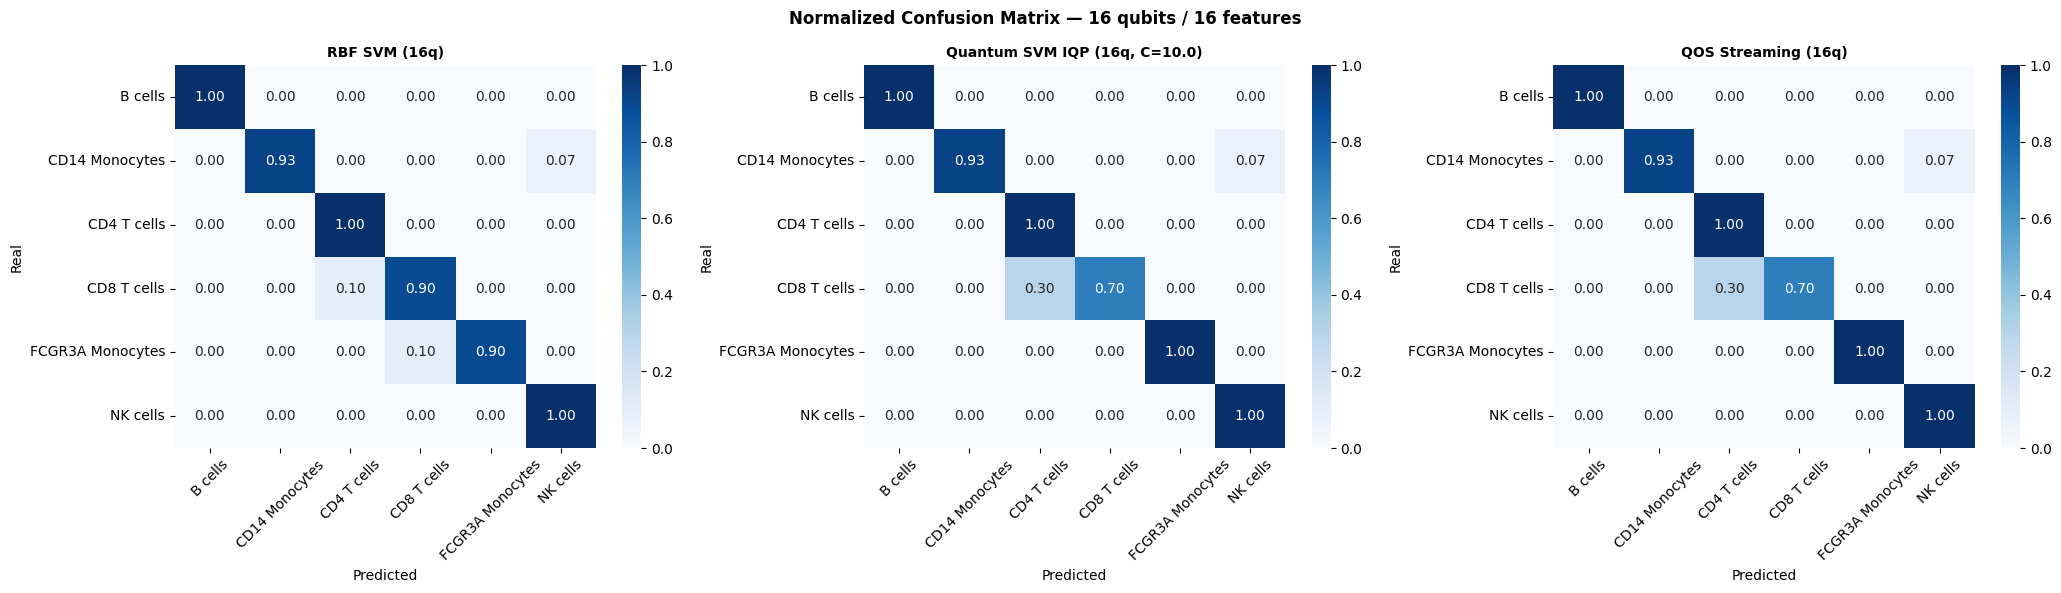

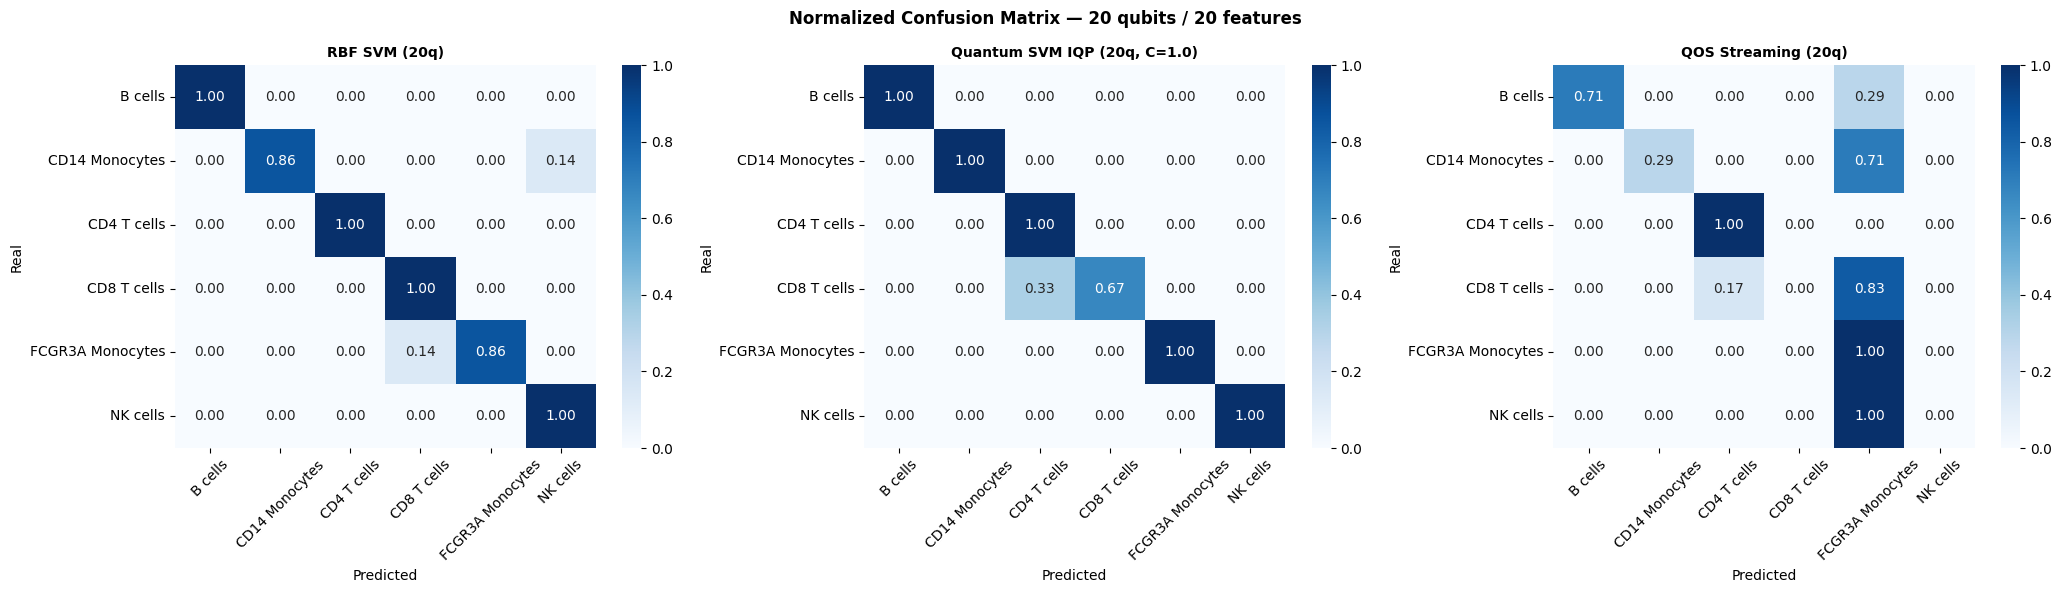

In [35]:
# Confusion Matrix for all configurations

def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    # Avoid divisions by zero if any row sums to 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm) # Convert NaNs to 0
        
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, vmin=0, vmax=1
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


# Loop for plotting and saving an image for every configuration of qubits
for r in curve_results:
    nq = r['n_qubits']
    nf = r['n_features']
    bC = r.get('best_C', '-')
    
    # Extract saved predictions
    y_true   = r['y_test']
    p_rbf    = r['pred_rbf']
    p_q      = r['pred_q']
    p_qos    = r['pred_qos']
    
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    
    plot_cm(y_true, p_rbf, f'RBF SVM ({nq}q)', axes[0]) 
    plot_cm(y_true, p_q,   f'Quantum SVM IQP ({nq}q, C={bC})', axes[1])
    plot_cm(y_true, p_qos, f'QOS Streaming ({nq}q)', axes[2])

    plt.suptitle(
        f'Normalized Confusion Matrix — {nq} qubits / {nf} features',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

## 8. Visualization of Gram matrices (Last point)

Visual comparison of the structure of the Gram matrix IQP vs the density of the QOS sketch.

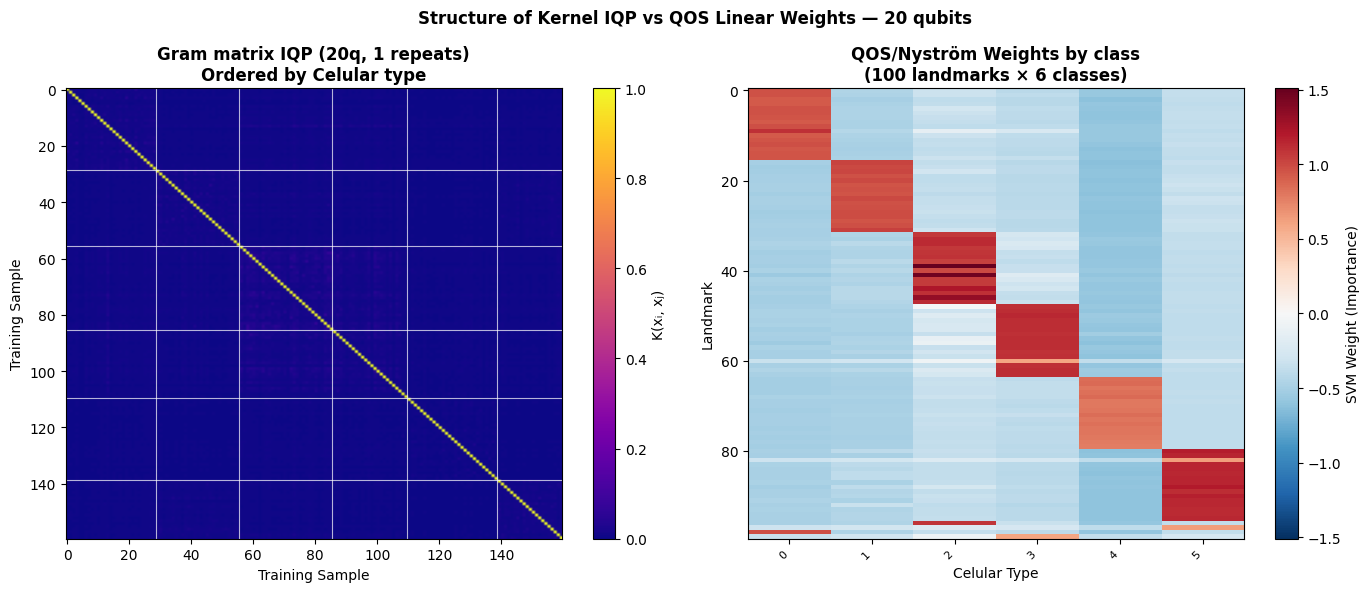

In [ ]:
sort_idx   = np.argsort(y_train)
K_sorted   = K_train[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gram matrix IQP ordered by class
im1 = axes[0].imshow(K_sorted, cmap='plasma', aspect='auto', vmin=0, vmax=1)
axes[0].set_title(
    f'Gram matrix IQP ({n_qubits}q, {n_repeats} repeats)\n'
    f'Ordered by Celular type',
    fontweight='bold'
)
axes[0].set_xlabel('Training Sample')
axes[0].set_ylabel('Training Sample')
plt.colorbar(im1, ax=axes[0], label='K(xᵢ, xⱼ)')

# Class separation lines
boundaries = np.cumsum([np.sum(y_train[sort_idx] == c) for c in range(n_classes-1)])
for b in boundaries:
    axes[0].axhline(b - 0.5, color='white', linewidth=0.8, alpha=0.7)
    axes[0].axvline(b - 0.5, color='white', linewidth=0.8, alpha=0.7)


# =========================================================
# NUEVO: Sketch QOS (Pesos del Linear SVM sobre los Landmarks)
# =========================================================
# Extraemos los coeficientes (pesos) de los SVMs binarios entrenados (OneVsRest)
# Cada SVM tiene un vector de pesos de tamaño (n_landmarks)
svm_weights = np.array([est.coef_[0] for est in qos.clf.estimators_])

# Transponemos para tener dimensiones (n_landmarks, n_classes)
sketch_display = svm_weights.T  

# Usamos un mapa de colores divergente (ej. coolwarm o RdBu) porque los pesos pueden ser negativos o positivos
# Centramos el colormap en 0 usando vmax y vmin simétricos
max_weight = np.max(np.abs(sketch_display))

im2 = axes[1].imshow(sketch_display, cmap='RdBu_r', aspect='auto', vmin=-max_weight, vmax=max_weight)
axes[1].set_title(
    f'QOS/Nyström Weights by class\n'
    f'({len(qos.landmarks_)} landmarks × {n_classes} classes)',
    fontweight='bold'
)
axes[1].set_xlabel('Celular Type')
axes[1].set_ylabel('Landmark')
axes[1].set_xticks(range(n_classes))

# Asegúrate de usar los nombres de clase correctos (ahora son 6)
axes[1].set_xticklabels(qos.classes_, rotation=45, ha='right', fontsize=8)
plt.colorbar(im2, ax=axes[1], label='SVM Weight (Importance)')

plt.suptitle(
    f'Structure of Kernel IQP vs QOS Linear Weights — {n_qubits} qubits',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Conclusions: Quantum vs Classical SVM on PBMC3k

This experiment reproduces the qubit scaling curve for a quantum kernel classification task on single-cell RNA sequencing data (PBMC3k), comparing a classical RBF SVM, a standard Quantum Kernel SVM (IQP), and a Quantum Oracle Sketching (QOS) model.

Based on the execution logs and performance metrics across 4 to 20 qubits, we can draw several critical conclusions regarding the scalability, performance, and current limitations of Quantum Machine Learning (QML) models.

### 1. The "Kernel Concentration" (Exponential Vanishing) Problem
The most significant finding of this experiment is the empirical observation of **kernel concentration** (also known as the exponential vanishing of inner products). 
* As the number of qubits ($D$) increases, the variance of the off-diagonal elements in the Gram matrix decays exponentially. 
* At 4 qubits, the variance is a healthy $7.20 \times 10^{-2}$. 
* By 20 qubits, the variance collapses to $2.60 \times 10^{-5}$, triggering the "KERNEL CONCENTRATION" warning. 
* **Implication:** In high-dimensional Hilbert spaces without appropriate scaling or inductive bias, the quantum state of any two distinct data points becomes essentially orthogonal. The kernel matrix approaches the identity matrix, meaning the model loses the ability to distinguish relative similarities between samples.

### 2. Catastrophic Failure of QOS at High Qubit Counts
The QOS (Quantum Oracle Sketching) method is designed to solve the $\mathcal{O}(N^2)$ memory bottleneck of traditional Quantum SVMs by projecting data against a subset of $L$ landmarks. 
* **Success at smaller scales:** Up to 16 qubits, QOS is highly competitive, achieving ~94% F1-score and proving that the Nyström-like approximation works effectively to reduce classical memory overhead.
* **Collapse at 20 qubits:** At 20 qubits, QOS performance completely crashes from 94.1% to **44.1% F1**. 
* **Why it fails:** Because the quantum kernel suffers from concentration at 20 qubits, evaluating a sample against the 100 landmarks yields a feature vector of near-zeros (or indistinguishably tiny values). The classical Linear SVM acting on top of these "sketched" features has no variance to learn from, resulting in random or collapsed predictions.

### 3. Quantum SVM vs. Classical RBF Baseline
* **Classical Robustness:** The classical RBF SVM baseline proved highly robust across all feature dimensions, maintaining an F1-score between 89% and 97%. It smoothly handles both low and high feature spaces.
* **Quantum Peak Performance:** The exact Quantum Kernel SVM (IQP) actually slightly outperformed the classical baseline at the **12-qubit** mark (98.1% vs 97.2% F1). This suggests a "sweet spot" where the expressiveness of the quantum feature space provides an advantage before the dimensionality becomes too large and concentration takes over.
* **Quantum Survival at 20q:** Surprisingly, the exact Quantum SVM maintained a 94.6% F1 at 20 qubits, avoiding the catastrophic failure seen in QOS. This is largely due to the **C-hyperparameter tuning**: an extremely regularized SVM ($C=1.0$) operating on the exact $\mathcal{O}(N^2)$ Gram matrix was able to squeeze out the remaining microscopic variance, though this is numerically fragile and scaling $N$ further would be computationally prohibitive.

### 4. More Qubits $\neq$ Better Performance
A common misconception in QML is that mapping data to larger numbers of qubits inherently improves model expressivity and accuracy. This experiment directly contradicts that:
* Performance increased from 4 to 12 qubits but plateaued and degraded beyond 16 qubits.
* Increasing the qubit count dilutes the data distribution in an exponentially large Hilbert space, requiring an exponentially larger dataset ($N$) to maintain density—a phenomenon known as the *curse of dimensionality*. However, to keep simulation times tractable, $N$ was actually *decreased* (from 800 down to 200) as qubits increased, further exacerbating the collapse.

### Summary Table of Dynamics
  Qubits      N   RBF Acc   RBF F1    Q Acc     Q F1   QOS Acc   QOS F1      K var    C opt
| Qubits | Kernel Variance | Status of Quantum Features | QOS F1 Score | Classical RBF F1 |
| :--- | :--- | :--- | :--- | :--- |
| **4** | $\sim 10^{-2}$ | Highly distinguishable | 87.7% | 89.6% |
| **8** | $\sim 10^{-3}$ | Highly distinguishable | 86.6% | 95.5% |
| **12** | $\sim 10^{-4}$ | **Optimal expressivity (Sweet Spot)** | **91.0%** | **97.2%** |
| **16** | $\sim 10^{-4}$ | Borderline / Degrading | 94.1% | 95.6% |
| **20** | $\sim 10^{-5}$ | **Concentrated (Collapsed)** | **44.1% (Failed)** | **94.9%** |